Accompanies Section `sec:spot_profile` (The Emergence and Decay Profile of Spots; Eq. `eqn:trapezoid`) and Appendix `app:fourier_trapezoid` (Fourier Transform of the Trapezoidal Envelope; Eq. `eq:alpha_piecewise`) of the paper.

# Fourier Transform of the Trapezoidal Spot Envelope $\alpha(t)$

We derive the Fourier transform $\hat{\alpha}(\omega)$ of the trapezoidal spot-size evolution $\alpha(t)$ analytically using SymPy, with the paper's convention $\hat f(\omega) = \int_{-\infty}^{\infty} f(t)\,e^{-i\omega t}\,dt$.

**Relation to the paper.** The paper does not typeset $\hat{\alpha}(\omega)$ or the autocorrelation $R_\alpha(\tau)$; they are what this notebook is about. The kernel only needs the *normalized squared* envelope $\Gamma(t) = \alpha^2(t)/\alpha_{\max}^2$, so the paper uses $\hat\Gamma(\omega)$ (Eq. `eq:Gamma_hat`, derived in Appendix `app:fourier_trapezoid`) and $R_\Gamma(\tau)$ (Eq. `eq:R_Gamma_closed`, Appendix `app:acf_trapezoid`) instead. Those are derived and checked in the companion notebook [`ft_squared_trapezoid.ipynb`](ft_squared_trapezoid.ipynb), which also reuses $\hat\alpha$ from here to check $\hat\Gamma$ by self-convolution.

**Key idea:** The trapezoid is the convolution of two rectangular pulses $\mathrm{rect}_W$ (pair `fp:rect` in Table `tab:fourier_pairs` of the paper):
$$\alpha(t) = \frac{\alpha_{\max}}{\tau_{\rm spot}}\,\left(\mathrm{rect}_{W_1} \ast \mathrm{rect}_{W_2}\right)(t), \qquad W_1 = \ell_{\rm spot} + \tau_{\rm spot}, \quad W_2 = \tau_{\rm spot}.$$

By the convolution property (`ft:convolution`), $\hat{\alpha}(\omega) = \frac{\alpha_{\max}}{\tau_{\rm spot}}\;\hat{\mathrm{rect}}_{W_1}(\omega)\,\hat{\mathrm{rect}}_{W_2}(\omega)$, i.e. a product of sinc functions.

In [1]:
import sympy as sp
from sympy import (pi, sin, cos, sqrt, exp, Abs, Rational, Piecewise, Heaviside,
                   symbols, integrate, oo, simplify, trigsimp, factor, cancel,
                   fourier_transform, Function, latex, init_printing)
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Math, display

init_printing(use_latex='mathjax')


def show(expr, lhs=''):
    """Display a SymPy expression using the paper's Heaviside symbol H (SymPy prints it as theta)."""
    display(Math(lhs + sp.latex(expr).replace(r'\theta', r'\mathsf{H}')))

## 1. Define the trapezoidal envelope

The paper's trapezoidal spot-size evolution (Eq. `eqn:trapezoid`, following Kipping 2012) is
$$\frac{\alpha_{\rm trap}(t)}{\alpha_{\max}} = \mathcal{I}^{-1}\left[\Delta t_1\,\mathsf{H}(\Delta t_1) - \Delta t_2\,\mathsf{H}(\Delta t_2)\right] - \mathcal{E}^{-1}\left[\Delta t_3\,\mathsf{H}(\Delta t_3) - \Delta t_4\,\mathsf{H}(\Delta t_4)\right],$$
with $\Delta t_1 = t - (t_{\rm ref} - \ell_{\rm spot}/2 - \tau_{\rm em})$, $\Delta t_2 = t - (t_{\rm ref} - \ell_{\rm spot}/2)$, $\Delta t_3 = t - (t_{\rm ref} + \ell_{\rm spot}/2)$, $\Delta t_4 = t - (t_{\rm ref} + \ell_{\rm spot}/2 + \tau_{\rm dec})$, normalizations $\mathcal{I} = \tau_{\rm em}$ and $\mathcal{E} = \tau_{\rm dec}$, and $\mathsf{H}$ the Heaviside step.

Here we take the symmetric case of Appendix `app:fourier_trapezoid`: $\tau_{\rm em} = \tau_{\rm dec} \equiv \tau_{\rm spot}$ and $t_{\rm ref} = 0$, so $\mathcal{I} = \mathcal{E} = \tau_{\rm spot}$ and
$$\alpha(t) = \frac{\alpha_{\max}}{\tau_{\rm spot}}\left[\Delta t_1\,\mathsf{H}(\Delta t_1) - \Delta t_2\,\mathsf{H}(\Delta t_2) - \Delta t_3\,\mathsf{H}(\Delta t_3) + \Delta t_4\,\mathsf{H}(\Delta t_4)\right]$$
where $\Delta t_1 = t + \ell_{\rm spot}/2 + \tau_{\rm spot}$, $\Delta t_2 = t + \ell_{\rm spot}/2$, $\Delta t_3 = t - \ell_{\rm spot}/2$, $\Delta t_4 = t - \ell_{\rm spot}/2 - \tau_{\rm spot}$. This is the piecewise trapezoid of Eq. `eq:alpha_piecewise` (both statements are checked in the next cell). The value of $\mathsf{H}(0)$ does not matter, since each step multiplies its own $\Delta t_i$; SymPy and NumPy use $\mathsf{H}(0) = 1/2$.

In [2]:
t = symbols('t', real=True)
omega = symbols('omega', real=True, nonzero=True)   # omega != 0 avoids SymPy's omega = 0 Piecewise branches;
                                                    # the DC value is taken as a limit in Section 5
ell, tau, alpha_max = symbols('ell_spot tau_spot alpha_max', positive=True)
t_ref = symbols('t_ref', real=True)
tau_em, tau_dec = symbols('tau_em tau_dec', positive=True)
H = lambda x: Heaviside(x, Rational(1, 2))

# Paper Eq. eqn:trapezoid (general t_ref, tau_em, tau_dec; I = tau_em, E = tau_dec)
D1 = t - (t_ref - ell/2 - tau_em)
D2 = t - (t_ref - ell/2)
D3 = t - (t_ref + ell/2)
D4 = t - (t_ref + ell/2 + tau_dec)
alpha_trap = alpha_max * ((D1*H(D1) - D2*H(D2)) / tau_em - (D3*H(D3) - D4*H(D4)) / tau_dec)

# Symmetric case, centered at t = 0
dt1 = t + ell/2 + tau
dt2 = t + ell/2
dt3 = t - ell/2
dt4 = t - ell/2 - tau

alpha_t = (alpha_max / tau) * (
    dt1 * H(dt1)
  - dt2 * H(dt2)
  - dt3 * H(dt3)
  + dt4 * H(dt4)
)

# Check 1: eqn:trapezoid with tau_em = tau_dec = tau_spot, t_ref = 0 reduces to alpha_t
sym_case = sp.expand(alpha_trap.subs({t_ref: 0, tau_em: tau, tau_dec: tau}) - alpha_t)
print("Eq. eqn:trapezoid (tau_em = tau_dec = tau_spot, t_ref = 0) == alpha(t):", sym_case == 0)
assert sym_case == 0

# Check 2: alpha_t equals the piecewise trapezoid of Eq. eq:alpha_piecewise
alpha_pw = alpha_max * Piecewise(
    (0, t < -ell/2 - tau),
    ((t + ell/2 + tau) / tau, t < -ell/2),
    (1, t <= ell/2),
    ((-t + ell/2 + tau) / tau, t <= ell/2 + tau),
    (0, True))
diff_pw = (alpha_t - alpha_pw).subs({ell: 20, tau: 5, alpha_max: Rational(1, 10)})
t_grid = [Rational(k, 4) for k in range(-80, 81)]     # t in [-20, 20], includes every break point
pw_match = all(diff_pw.subs(t, tv) == 0 for tv in t_grid)
print("Heaviside form == Eq. eq:alpha_piecewise (exact, on a grid through all break points):", pw_match)
assert pw_match

show(alpha_t, r'\alpha(t) = ')

Eq. eqn:trapezoid (tau_em = tau_dec = tau_spot, t_ref = 0) == alpha(t): True
Heaviside form == Eq. eq:alpha_piecewise (exact, on a grid through all break points): True


<IPython.core.display.Math object>

## 1b. Direct Fourier transform of $\alpha(t)$ from the piecewise form

The trapezoid (Eq. `eq:alpha_piecewise`) has compact support on $[-(\ell_{\rm spot}/2 + \tau_{\rm spot}),\; \ell_{\rm spot}/2 + \tau_{\rm spot}]$ with three segments (writing $\ell \equiv \ell_{\rm spot}$ and $\tau \equiv \tau_{\rm spot}$, as in Appendix `app:fourier_trapezoid`):

| Segment | Interval | $\alpha(t)$ |
|---------|----------|-------------|
| Rising ramp | $-\ell/2 - \tau \le t < -\ell/2$ | $\alpha_{\max}(t + \ell/2 + \tau)/\tau$ |
| Plateau | $-\ell/2 \le t \le \ell/2$ | $\alpha_{\max}$ |
| Falling ramp | $\ell/2 < t \le \ell/2 + \tau$ | $\alpha_{\max}(\ell/2 + \tau - t)/\tau$ |

We compute $\hat{\alpha}(\omega) = \int_{-\infty}^{\infty}\alpha(t)\,e^{-i\omega t}\,dt$ as the sum of three integrals. This is the linear-ramp analogue of the paper's direct integration of $\hat\Gamma(\omega)$ (Eqs. `eq:I1_plateau` to `eq:Gamma_hat_direct`).

In [3]:
# Integration limits
a = -ell/2 - tau   # start of rising ramp
b = -ell/2         # end of rising ramp / start of plateau
c =  ell/2         # end of plateau / start of falling ramp
d =  ell/2 + tau   # end of falling ramp

# --- Segment 1: Rising ramp ---
integrand_rise = alpha_max * (t - a) / tau * exp(-sp.I * omega * t)
I_rise = integrate(integrand_rise, (t, a, b))
I_rise = simplify(I_rise)
print("I_rise =")
display(I_rise)

I_rise =


                                   ⅈ⋅ellₛₚₒₜ⋅ω
                                   ───────────
     ⎛             ⅈ⋅ω⋅τₛₚₒₜ    ⎞       2     
αₘₐₓ⋅⎝ⅈ⋅ω⋅τₛₚₒₜ - ℯ          + 1⎠⋅ℯ           
──────────────────────────────────────────────
                    2                         
                   ω ⋅τₛₚₒₜ                   

In [4]:
# --- Segment 2: Plateau ---
integrand_plat = alpha_max * exp(-sp.I * omega * t)
I_plat = integrate(integrand_plat, (t, b, c))
I_plat = simplify(I_plat)
print("I_plat =")
display(I_plat)

I_plat =


          ⎛ellₛₚₒₜ⋅ω⎞
2⋅αₘₐₓ⋅sin⎜─────────⎟
          ⎝    2    ⎠
─────────────────────
          ω          

In [5]:
# --- Segment 3: Falling ramp ---
integrand_fall = alpha_max * (d - t) / tau * exp(-sp.I * omega * t)
I_fall = integrate(integrand_fall, (t, c, d))
I_fall = simplify(I_fall)
print("I_fall =")
display(I_fall)

I_fall =


                                                     ⎛ellₛₚₒₜ        ⎞
                                                -ⅈ⋅ω⋅⎜─────── + τₛₚₒₜ⎟
     ⎛             ⅈ⋅ω⋅τₛₚₒₜ    ⅈ⋅ω⋅τₛₚₒₜ    ⎞       ⎝   2           ⎠
αₘₐₓ⋅⎝- ⅈ⋅ω⋅τₛₚₒₜ⋅ℯ          + ℯ          - 1⎠⋅ℯ                      
──────────────────────────────────────────────────────────────────────
                                2                                     
                               ω ⋅τₛₚₒₜ                               

In [6]:
# --- Total: sum of three segments ---
alpha_hat_direct = simplify(I_rise + I_plat + I_fall)
print("alpha_hat(omega) [direct] =")
display(alpha_hat_direct)

alpha_hat(omega) [direct] =


     ⎛                                    ⅈ⋅ω⋅(ellₛₚₒₜ + 2⋅τₛₚₒₜ)              ↪
     ⎜                                    ───────────────────────              ↪
     ⎜             ⅈ⋅ω⋅τₛₚₒₜ                         2               ⎛ellₛₚₒₜ⋅ ↪
αₘₐₓ⋅⎜- ⅈ⋅ω⋅τₛₚₒₜ⋅ℯ          + 2⋅ω⋅τₛₚₒₜ⋅ℯ                       ⋅sin⎜──────── ↪
     ⎝                                                               ⎝    2    ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                               ↪

↪                                                                          ⎞   ↪
↪                                                                          ⎟   ↪
↪ ω⎞   ⎛             ⅈ⋅ω⋅τₛₚₒₜ    ⎞  ⅈ⋅ω⋅(ellₛₚₒₜ + τₛₚₒₜ)    ⅈ⋅ω⋅τₛₚₒₜ    ⎟   ↪
↪ ─⎟ + ⎝ⅈ⋅ω⋅τₛₚₒₜ - ℯ          + 1⎠⋅ℯ                      + ℯ          - 1⎟⋅ℯ ↪
↪  ⎠                       

### Verify the direct FT matches the sinc-product form (derived in Section 3 below)

In [7]:
# Sinc-product form from Section 3: rect widths W1 = ell_spot + tau_spot, W2 = tau_spot
W1_val = ell + tau
W2_val = tau
alpha_hat_sinc = (alpha_max / tau) * (2 * sin(omega * W1_val / 2) / omega) * (2 * sin(omega * W2_val / 2) / omega)

# Symbolic check: rewrite the sines as exponentials and simplify the difference
diff_sym = simplify((alpha_hat_direct - alpha_hat_sinc).rewrite(exp))
print("Symbolic match (direct == sinc-product):", diff_sym == 0)
assert diff_sym == 0

# Numerical check
f_direct = sp.lambdify((omega, ell, tau, alpha_max), alpha_hat_direct, 'numpy')
f_sinc = sp.lambdify((omega, ell, tau, alpha_max), alpha_hat_sinc, 'numpy')

test_w = np.linspace(0.01, 5, 500)
v_direct = np.real(f_direct(test_w, 20.0, 5.0, 0.1))
v_sinc = np.real(f_sinc(test_w, 20.0, 5.0, 0.1))

max_err = np.max(np.abs(v_direct - v_sinc))
print(f"Numerical max |direct - sinc-product|: {max_err:.2e}")
print(f"Match: {max_err < 1e-12}")
assert max_err < 1e-12

Symbolic match (direct == sinc-product): True
Numerical max |direct - sinc-product|: 1.82e-14
Match: True


## 2. Fourier transform of a rectangular pulse

The FT of $\mathrm{rect}_W(t) = \begin{cases}1 & |t| \le W/2 \\ 0 & \text{otherwise}\end{cases}$ (pair `fp:rect` in Table `tab:fourier_pairs` of the paper) is:

$$\hat{\mathrm{rect}}_W(\omega) = \int_{-W/2}^{W/2} e^{-i\omega t}\,dt = W\,\mathrm{sinc}\!\left(\frac{\omega W}{2}\right)$$

where $\mathrm{sinc}(x) = \sin(x)/x$.

In [8]:
W = symbols('W', positive=True)

# FT of rect_W(t) by direct integration
rect_ft = integrate(exp(-sp.I * omega * t), (t, -W/2, W/2))
rect_ft_simplified = simplify(rect_ft)

print("FT of rect_W(t) =")
rect_ft_simplified

FT of rect_W(t) =


     ⎛W⋅ω⎞
2⋅sin⎜───⎟
     ⎝ 2 ⎠
──────────
    ω     

In [9]:
# Verify it equals W * sinc(omega*W/2) = W * sin(omega*W/2) / (omega*W/2) = 2*sin(omega*W/2)/omega
rect_ft_sinc = 2 * sin(omega * W / 2) / omega
print("Expected: 2*sin(omega*W/2)/omega")
print("Match:", simplify(rect_ft_simplified - rect_ft_sinc) == 0)
assert simplify(rect_ft_simplified - rect_ft_sinc) == 0
rect_ft_sinc

Expected: 2*sin(omega*W/2)/omega
Match: True


     ⎛W⋅ω⎞
2⋅sin⎜───⎟
     ⎝ 2 ⎠
──────────
    ω     

## 3. Trapezoid as convolution of two rectangles

The convolution of $\mathrm{rect}_{W_1}$ and $\mathrm{rect}_{W_2}$ (with $W_1 > W_2$) is a trapezoid with
- plateau width $W_1 - W_2$,
- ramp width $W_2$ on each side,
- total support $W_1 + W_2$,
- peak height $W_2$ (the overlap length while the narrow pulse lies inside the wide one).

Eq. `eq:alpha_piecewise` has plateau $\ell_{\rm spot}$, ramps $\tau_{\rm spot}$, total support $\ell_{\rm spot} + 2\tau_{\rm spot}$ and peak $\alpha_{\max}$. Matching:

- $\mathrm{rect}_{W_1}$: width $W_1 = \ell_{\rm spot} + \tau_{\rm spot}$
- $\mathrm{rect}_{W_2}$: width $W_2 = \tau_{\rm spot}$
- prefactor $\alpha_{\max}/W_2 = \alpha_{\max}/\tau_{\rm spot}$, so that the peak is $\alpha_{\max}$:
$$\alpha(t) = \frac{\alpha_{\max}}{\tau_{\rm spot}}\,\left(\mathrm{rect}_{W_1} \ast \mathrm{rect}_{W_2}\right)(t).$$

The next cell checks this in the time domain. By the convolution property (`ft:convolution`), $\hat{\alpha}(\omega) = \frac{\alpha_{\max}}{\tau_{\rm spot}}\;\hat{\mathrm{rect}}_{W_1}(\omega)\,\hat{\mathrm{rect}}_{W_2}(\omega)$.

In [10]:
# Widths of the two rectangles
W1 = ell + tau   # W1 - W2 = ell (plateau), W1 + W2 = ell + 2*tau (total support)
W2 = tau         # ramp width (and peak height of rect_W1 * rect_W2)

# Time-domain check: (alpha_max/tau_spot) * (rect_W1 * rect_W2)(t) == Eq. eq:alpha_piecewise
ell_n, tau_n, amax_n, dt_n = 20.0, 5.0, 0.1, 0.01
tt = np.arange(-4000, 4001) * dt_n                        # odd length, t = 0 at the center
rect = lambda x, Wd: (np.abs(x) <= Wd / 2).astype(float)
conv_rects = np.convolve(rect(tt, ell_n + tau_n), rect(tt, tau_n), mode='same') * dt_n * amax_n / tau_n
alpha_pw_num = amax_n * np.clip((ell_n / 2 + tau_n - np.abs(tt)) / tau_n, 0, 1)   # Eq. eq:alpha_piecewise
conv_err = np.max(np.abs(conv_rects - alpha_pw_num))
print(f"max |(alpha_max/tau) rect_W1 * rect_W2 - alpha(t)| = {conv_err:.1e}  "
      f"(grid step dt = {dt_n}, so O(dt * alpha_max/tau) = {dt_n * amax_n / tau_n:.0e} expected)")
assert conv_err < 3 * dt_n * amax_n / tau_n

# FT of each rectangle: 2*sin(omega*W/2)/omega
Rect1_hat = 2 * sin(omega * W1 / 2) / omega
Rect2_hat = 2 * sin(omega * W2 / 2) / omega

# FT of the trapezoid = (alpha_max / tau_spot) * Rect1_hat * Rect2_hat
alpha_hat = (alpha_max / tau) * Rect1_hat * Rect2_hat
alpha_hat_simplified = simplify(alpha_hat)

print("alpha_hat(omega) = (alpha_max / tau_spot) * rect_hat_W1 * rect_hat_W2 =")
alpha_hat_simplified

max |(alpha_max/tau) rect_W1 * rect_W2 - alpha(t)| = 2.0e-04  (grid step dt = 0.01, so O(dt * alpha_max/tau) = 2e-04 expected)
alpha_hat(omega) = (alpha_max / tau_spot) * rect_hat_W1 * rect_hat_W2 =


          ⎛ω⋅τₛₚₒₜ⎞    ⎛ω⋅(ellₛₚₒₜ + τₛₚₒₜ)⎞
4⋅αₘₐₓ⋅sin⎜───────⎟⋅sin⎜───────────────────⎟
          ⎝   2   ⎠    ⎝         2         ⎠
────────────────────────────────────────────
                   2                        
                  ω ⋅τₛₚₒₜ                  

## 4. Simplify using product-to-sum identity

Use $\sin A\,\sin B = \tfrac{1}{2}[\cos(A-B) - \cos(A+B)]$ to convert the product of sines into a difference of cosines:

$$\hat{\alpha}(\omega) = \frac{4\,\alpha_{\max}}{\omega^2\,\tau_{\rm spot}}\sin\!\left(\frac{\omega(\ell_{\rm spot}+\tau_{\rm spot})}{2}\right)\sin\!\left(\frac{\omega\,\tau_{\rm spot}}{2}\right)$$

In [11]:
# Apply product-to-sum: sin(A)*sin(B) = [cos(A-B) - cos(A+B)] / 2
A = omega * (ell + tau) / 2
B = omega * tau / 2

# The sinc-product form
product_form = 4 * alpha_max / (omega**2 * tau) * sin(A) * sin(B)

# Expand using trig identity
cosine_form = 4 * alpha_max / (omega**2 * tau) * (cos(A - B) - cos(A + B)) / 2

# Simplify A-B and A+B
A_minus_B = simplify(A - B)
A_plus_B = simplify(A + B)

print(f"A = omega*(ell_spot + tau_spot)/2")
print(f"B = omega*tau_spot/2")
print(f"A - B = {A_minus_B}  =  omega*ell_spot/2")
print(f"A + B = {A_plus_B}  =  omega*ell_spot/2 + omega*tau_spot")
print()

# Final cosine-difference form
alpha_hat_final = 2 * alpha_max / (omega**2 * tau) * (
    cos(omega * ell / 2) - cos(omega * ell / 2 + omega * tau)
)

# Verify equivalence
print("Sinc-product == cosine-difference form?",
      simplify(sp.expand_trig(product_form) - sp.expand_trig(cosine_form)) == 0)
print()
print("Result:")
alpha_hat_final

A = omega*(ell_spot + tau_spot)/2
B = omega*tau_spot/2
A - B = ell_spot*omega/2  =  omega*ell_spot/2
A + B = omega*(ell_spot + 2*tau_spot)/2  =  omega*ell_spot/2 + omega*tau_spot

Sinc-product == cosine-difference form? True

Result:


       ⎛   ⎛ellₛₚₒₜ⋅ω⎞      ⎛ellₛₚₒₜ⋅ω          ⎞⎞
2⋅αₘₐₓ⋅⎜cos⎜─────────⎟ - cos⎜───────── + ω⋅τₛₚₒₜ⎟⎟
       ⎝   ⎝    2    ⎠      ⎝    2              ⎠⎠
──────────────────────────────────────────────────
                      2                           
                     ω ⋅τₛₚₒₜ                     

## 5. Summary

From the convolution theorem, the FT of the trapezoidal envelope is:

$$\boxed{\hat{\alpha}(\omega) = \frac{4\,\alpha_{\max}}{\omega^2\,\tau_{\rm spot}}\sin\!\left(\frac{\omega(\ell_{\rm spot}+\tau_{\rm spot})}{2}\right)\sin\!\left(\frac{\omega\,\tau_{\rm spot}}{2}\right)}$$

Or equivalently, using the product-to-sum identity $\sin A\sin B = \frac{1}{2}[\cos(A-B)-\cos(A+B)]$:

$$\hat{\alpha}(\omega) = \frac{2\,\alpha_{\max}}{\omega^2\,\tau_{\rm spot}}\left[\cos\!\left(\frac{\omega\,\ell_{\rm spot}}{2}\right) - \cos\!\left(\frac{\omega\,\ell_{\rm spot}}{2} + \omega\,\tau_{\rm spot}\right)\right]$$

It falls off as $\omega^{-2}$ at high frequency, because $\alpha(t)$ has slope discontinuities at its four corners. The value at $\omega = 0$ (by L'Hôpital, or $\alpha_{\max} W_1 W_2/\tau_{\rm spot}$ from the sinc product) is $\hat{\alpha}(0) = \alpha_{\max}(\ell_{\rm spot} + \tau_{\rm spot})$: the area under the trapezoid (plateau $\alpha_{\max}\ell_{\rm spot}$ plus two triangles of $\tfrac12\alpha_{\max}\tau_{\rm spot}$).

For comparison, the paper's normalized squared envelope has $\hat\Gamma(0) = \ell_{\rm spot} + 2\tau_{\rm spot}/3$ (Eq. `eq:Gamma_hat` at $\omega \to 0$; see `ft_squared_trapezoid.ipynb`).

In [12]:
# Verify alpha_hat(0) = alpha_max * (ell + tau) via limit
# Total area = plateau * height + 2 * (0.5 * ramp * height) = ell*alpha_max + tau*alpha_max
alpha_hat_at_0 = sp.limit(alpha_hat_simplified, omega, 0)
expected = alpha_max * (ell + tau)
print(f"alpha_hat(0) = {alpha_hat_at_0}")
print(f"Expected: alpha_max * (ell_spot + tau_spot) = {expected}")
print(f"Match: {simplify(alpha_hat_at_0 - expected) == 0}")
assert simplify(alpha_hat_at_0 - expected) == 0

# Same value from the time-domain area of Eq. eq:alpha_piecewise
area = integrate(alpha_pw, (t, -ell/2 - tau, ell/2 + tau))
print(f"Area under alpha(t): {simplify(area)}")
assert simplify(area - expected) == 0

alpha_hat(0) = alpha_max*(ell_spot + tau_spot)
Expected: alpha_max * (ell_spot + tau_spot) = alpha_max*(ell_spot + tau_spot)
Match: True
Area under alpha(t): alpha_max*(ell_spot + tau_spot)


## 6. Numerical verification: analytic FT vs FFT

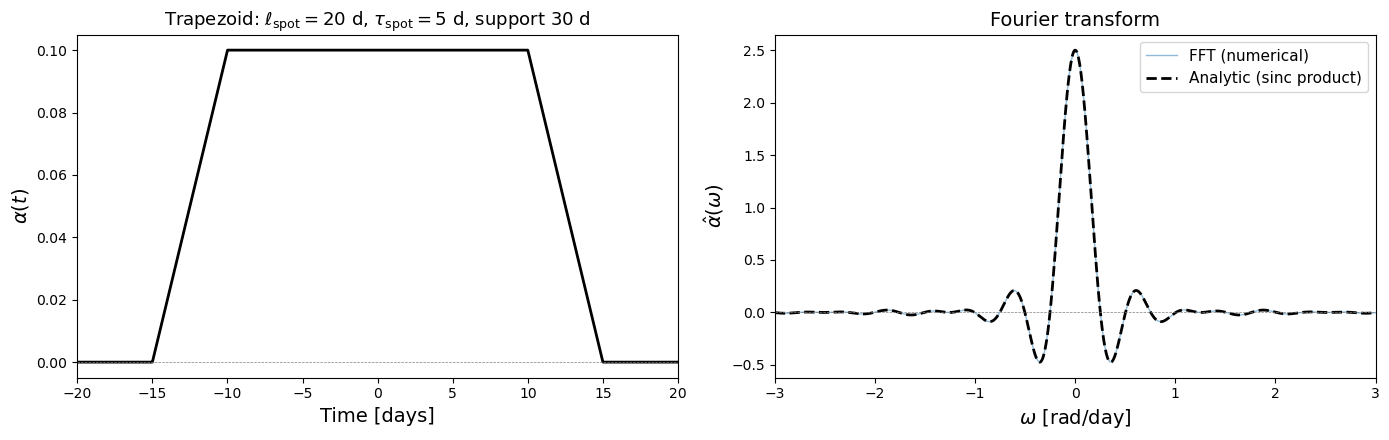

Max |FFT - analytic| for |omega| < 3: 1.66e-07


In [13]:
# Numeric parameters
ell_val = 20.0
tau_val = 5.0
amax_val = 0.1

# Build the trapezoid in time domain (Heaviside form)
def trapezoid(t, ell_s, tau_s, a_max):
    """alpha(t): Eq. eqn:trapezoid with tau_em = tau_dec = tau_s, t_ref = 0 (= Eq. eq:alpha_piecewise)."""
    dt1 = t + ell_s/2 + tau_s
    dt2 = t + ell_s/2
    dt3 = t - ell_s/2
    dt4 = t - ell_s/2 - tau_s
    alpha = a_max / tau_s * (
        dt1 * np.heaviside(dt1, 0.5) - dt2 * np.heaviside(dt2, 0.5)
      - dt3 * np.heaviside(dt3, 0.5) + dt4 * np.heaviside(dt4, 0.5)
    )
    return alpha

# Analytic FT (sinc-product form: W1 = ell_spot + tau_spot, W2 = tau_spot)
def alpha_hat_analytic(w, ell_s, tau_s, a_max):
    W1 = ell_s + tau_s
    W2 = tau_s
    with np.errstate(divide='ignore', invalid='ignore'):
        sinc1 = np.where(np.abs(w) < 1e-15, W1, 2*np.sin(w*W1/2)/w)
        sinc2 = np.where(np.abs(w) < 1e-15, W2, 2*np.sin(w*W2/2)/w)
    return a_max / tau_s * sinc1 * sinc2

# Numerical FFT
N = 2**16
dt = 0.005
t_arr = np.arange(-N//2, N//2) * dt
alpha_arr = trapezoid(t_arr, ell_val, tau_val, amax_val)

# FFT (shift so that t=0 is at center)
fft_vals = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(alpha_arr))) * dt
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=dt)) * 2 * np.pi  # angular frequency

# Analytic
w_plot = np.linspace(-3, 3, 1000)
analytic_vals = alpha_hat_analytic(w_plot, ell_val, tau_val, amax_val)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: time domain
t_plot = np.linspace(-20, 20, 2000)
axes[0].plot(t_plot, trapezoid(t_plot, ell_val, tau_val, amax_val), 'k-', lw=2)
axes[0].set_xlabel('Time [days]', fontsize=14)
axes[0].set_ylabel(r'$\alpha(t)$', fontsize=14)
axes[0].set_title(rf'Trapezoid: $\ell_{{\rm spot}}={ell_val:g}$ d, $\tau_{{\rm spot}}={tau_val:g}$ d, support ${ell_val+2*tau_val:g}$ d', fontsize=13)
axes[0].set_xlim(-20, 20)
axes[0].axhline(0, color='gray', lw=0.5, ls='--')

# Right: frequency domain
axes[1].plot(freqs, np.real(fft_vals), 'C0-', lw=1, alpha=0.5, label='FFT (numerical)')
axes[1].plot(w_plot, analytic_vals, 'k--', lw=2, label='Analytic (sinc product)')
axes[1].set_xlabel(r'$\omega$ [rad/day]', fontsize=14)
axes[1].set_ylabel(r'$\hat{\alpha}(\omega)$', fontsize=14)
axes[1].set_title('Fourier transform', fontsize=14)
axes[1].set_xlim(-3, 3)
axes[1].legend(fontsize=11)
axes[1].axhline(0, color='gray', lw=0.5, ls='--')

plt.tight_layout()
plt.show()

# Quantify agreement
mask = np.abs(freqs) < 3
interp_analytic = alpha_hat_analytic(freqs[mask], ell_val, tau_val, amax_val)
max_err = np.max(np.abs(np.real(fft_vals[mask]) - interp_analytic))
print(f"Max |FFT - analytic| for |omega| < 3: {max_err:.2e}")
assert max_err < 1e-4 * amax_val * (ell_val + tau_val)

## 7. Autocorrelation $R_\alpha(\tau)$ via Wiener–Khinchin

The autocorrelation of the (unsquared) trapezoid, $R_\alpha(\tau) = \int\alpha(t)\,\alpha(t+\tau)\,dt$, follows from the Wiener–Khinchin theorem (Eq. `eq:wk`) applied to the power spectral density $S_\alpha(\omega) = |\hat\alpha(\omega)|^2$:

$$R_\alpha(\tau) = \frac{1}{2\pi}\int_{-\infty}^{\infty} |\hat{\alpha}(\omega)|^2\,e^{i\omega\tau}\,d\omega$$

Since $\hat{\alpha}(\omega)$ is a product of sincs, $|\hat{\alpha}(\omega)|^2$ is a product of $\mathrm{sinc}^2$ functions, whose inverse FT is a convolution of two triangle functions (each the autocorrelation of a $\mathrm{rect}_W$), yielding a piecewise cubic polynomial.

**This is not the envelope term of the paper's kernel.** The kernel (Eq. `eq:kernel_single_spot`) contains $\alpha_{\max}^4 R_\Gamma(\tau)$, the autocorrelation of the normalized squared envelope $\Gamma = \alpha^2/\alpha_{\max}^2$ (closed form in Eq. `eq:R_Gamma_closed`, a piecewise quintic; see `ft_squared_trapezoid.ipynb` for $\hat\Gamma$). The two are linked at zero lag: $R_\alpha(0) = \int\alpha^2\,dt = \alpha_{\max}^2\,\hat\Gamma(0) = \alpha_{\max}^2(\ell_{\rm spot} + 2\tau_{\rm spot}/3)$, checked below.

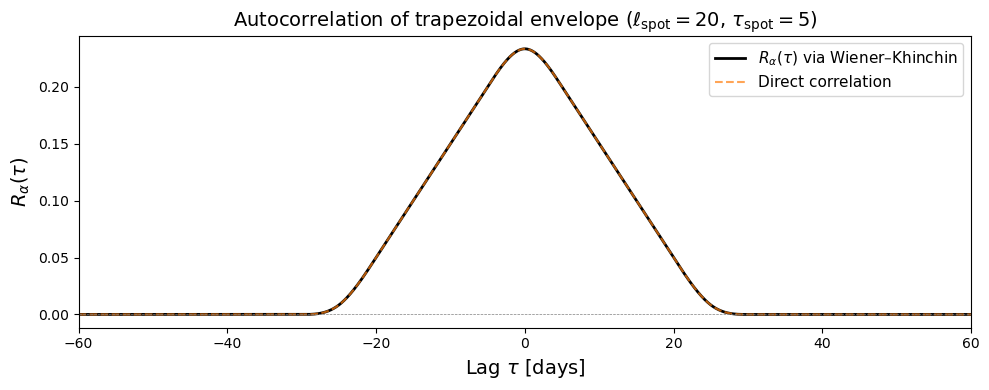

max |R_alpha (Wiener-Khinchin) - R_alpha (direct)| = 1.94e-16
R_alpha(0) numerical = 0.233333
alpha_max^2 * (ell_spot + 2 tau_spot/3) = alpha_max^2 * Gamma_hat(0) = 0.233333


In [14]:
# Compute R_alpha(tau) numerically via inverse FFT of the PSD S_alpha = |alpha_hat|^2
S_alpha = np.abs(fft_vals)**2

# Inverse FFT to get autocorrelation
R_alpha_fft = np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(S_alpha))) / dt
tau_arr = t_arr  # same grid

# Also compute by direct time-domain correlation
from scipy.signal import correlate
R_alpha_direct = correlate(alpha_arr, alpha_arr, mode='same') * dt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tau_arr, np.real(R_alpha_fft), 'k-', lw=2, label=r'$R_\alpha(\tau)$ via Wiener–Khinchin')
ax.plot(tau_arr, R_alpha_direct, 'C1--', lw=1.5, alpha=0.7, label=r'Direct correlation')
ax.set_xlabel(r'Lag $\tau$ [days]', fontsize=14)
ax.set_ylabel(r'$R_\alpha(\tau)$', fontsize=14)
ax.set_title(rf'Autocorrelation of trapezoidal envelope ($\ell_{{\rm spot}}={ell_val:g}$, $\tau_{{\rm spot}}={tau_val:g}$)', fontsize=14)
ax.set_xlim(-60, 60)
ax.legend(fontsize=11)
ax.axhline(0, color='gray', lw=0.5, ls='--')
plt.tight_layout()
plt.show()

# Wiener-Khinchin vs direct correlation, and the zero-lag link to Gamma_hat(0)
wk_err = np.max(np.abs(np.real(R_alpha_fft) - R_alpha_direct))
R0_expected = amax_val**2 * (ell_val + 2 * tau_val / 3)      # alpha_max^2 * Gamma_hat(0)
R0_num = np.real(R_alpha_fft)[N // 2]                         # tau = 0 sits at index N//2
print(f"max |R_alpha (Wiener-Khinchin) - R_alpha (direct)| = {wk_err:.2e}")
print(f"R_alpha(0) numerical = {R0_num:.6f}")
print(f"alpha_max^2 * (ell_spot + 2 tau_spot/3) = alpha_max^2 * Gamma_hat(0) = {R0_expected:.6f}")
assert wk_err < 1e-8 and abs(R0_num / R0_expected - 1) < 1e-4